
>>> Top 10 Most Influential Medical Parameters:
hba1c                                 0.679397
glucose_postprandial                  0.629832
glucose_fasting                       0.510919
family_history_diabetes               0.197926
age                                   0.137713
physical_activity_minutes_per_week    0.100774
bmi                                   0.097057
systolic_bp                           0.095481
waist_to_hip_ratio                    0.078918
ldl_cholesterol                       0.067475
dtype: float64
>>> Plot saved successfully as 'top10_diabetes_params.png'


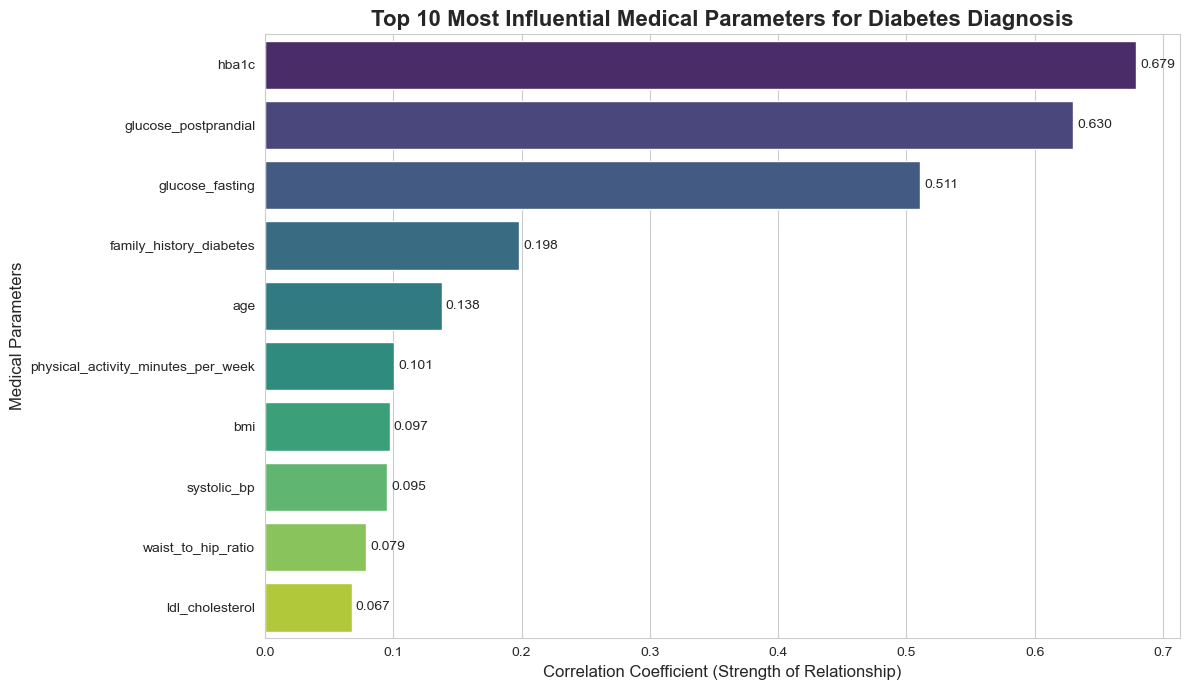

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

file_path = '/Users/aslinuraksakal/EE473/diabetes_dataset.csv'
df = pd.read_csv(file_path)

numeric_df = df.select_dtypes(include=['float64', 'int64'])

correlations = numeric_df.corrwith(df['diagnosed_diabetes']).abs()

correlations = correlations.drop('diagnosed_diabetes')

if 'diabetes_risk_score' in correlations:
    correlations = correlations.drop('diabetes_risk_score')

top_10 = correlations.sort_values(ascending=False).head(10)

print("\n>>> Top 10 Most Influential Medical Parameters:")
print(top_10)

plt.figure(figsize=(12, 7))

ax = sns.barplot(x=top_10.values, y=top_10.index, palette='viridis', hue=top_10.index, legend=False)

plt.title('Top 10 Most Influential Medical Parameters for Diabetes Diagnosis', fontsize=16, fontweight='bold')
plt.xlabel('Correlation Coefficient (Strength of Relationship)', fontsize=12)
plt.ylabel('Medical Parameters', fontsize=12)

for i in ax.containers:
    ax.bar_label(i, fmt='%.3f', padding=3)
plt.tight_layout()
plt.savefig('top10_diabetes_params.png', dpi=300, bbox_inches='tight')
plt.show()